In [1]:
#This jupyter notebook is the testing environment for the rocket3 simulator done by Aitor Pérez Grau


In [2]:
# 0) importation of the necessary classes
from simulator_3dof.simulation import flight_3dof
from simulator_3dof.simulation import rocket_3dof
from simulator_3dof.simulation import motor_3dof
from simulator_3dof.simulation.atmosphere import atmosphere


In [3]:
# 1) Definition of the atmosphere
test_atm = atmosphere()
print(test_atm)
print(test_atm.density_func)

In [4]:
# 2) Creation of the motor
test_motor_eng_file = motor_3dof(thrust = '/Users/aitorpg/Documents/LEARNING/3DOF_simulator/tests/extra_files/M1128_95.eng', name = 'thrust_eng_file_motor')
test_motor_constant_thrust = motor_3dof(thrust = 1100 , burn_out_time = 6, name = 'constant_thrust')



In [5]:
# 3) Definition of the rocket
test_rocket_3dof = rocket_3dof(
    dry_mass = 14.035, 
    fuel_mass = 3.095,
    on_drag_coefficient = 0.3, 
    off_drag_coefficient= 0.75,
    radius = 0.057,
    )

In [6]:
# 4) Addition of the motor to the rocket
test_rocket_3dof.add_motor(test_motor_constant_thrust)

In [7]:
# 4) definition of the fligth 
test_flight_3dof = flight_3dof(
    rocket = test_rocket_3dof,
    atm = test_atm, 
    initial_altitude = 10,
    inclination = 85,
    heading = -15
)

In [8]:
# 3) simulation
test_flight_3dof.simulate()



Apogee conditions: 
Apogee Height ASL: 3604.222809809742
Apogee X: -306.47901766594686
Apogee Y: 1143.7952653830766
Apogee time: 26.183000000009017

Impact conditions: 
Downrange impact: 2020.507900858988
Impact time: 58.098999999955296


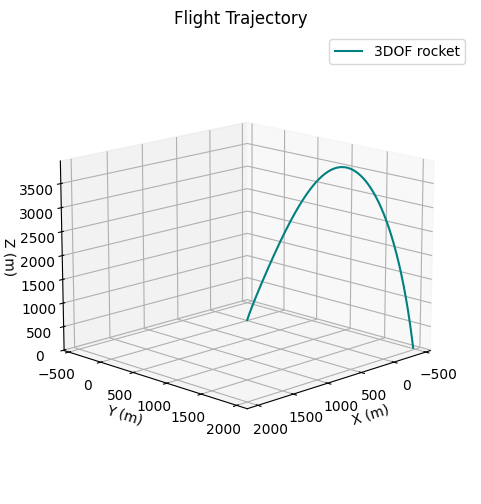

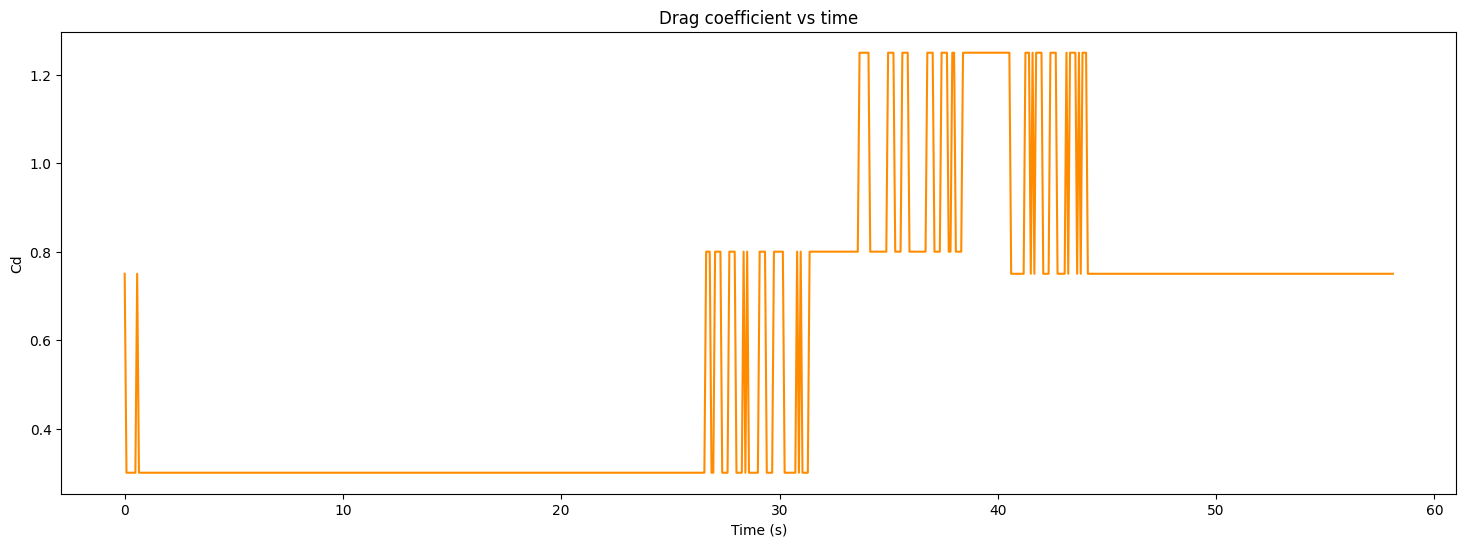

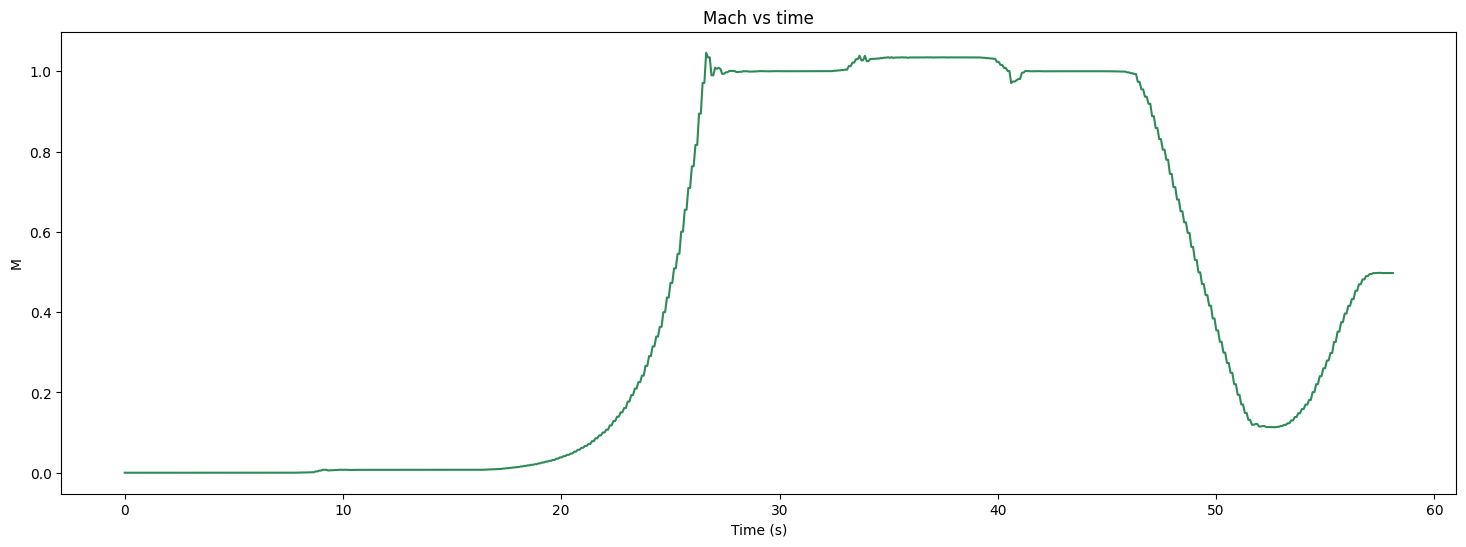

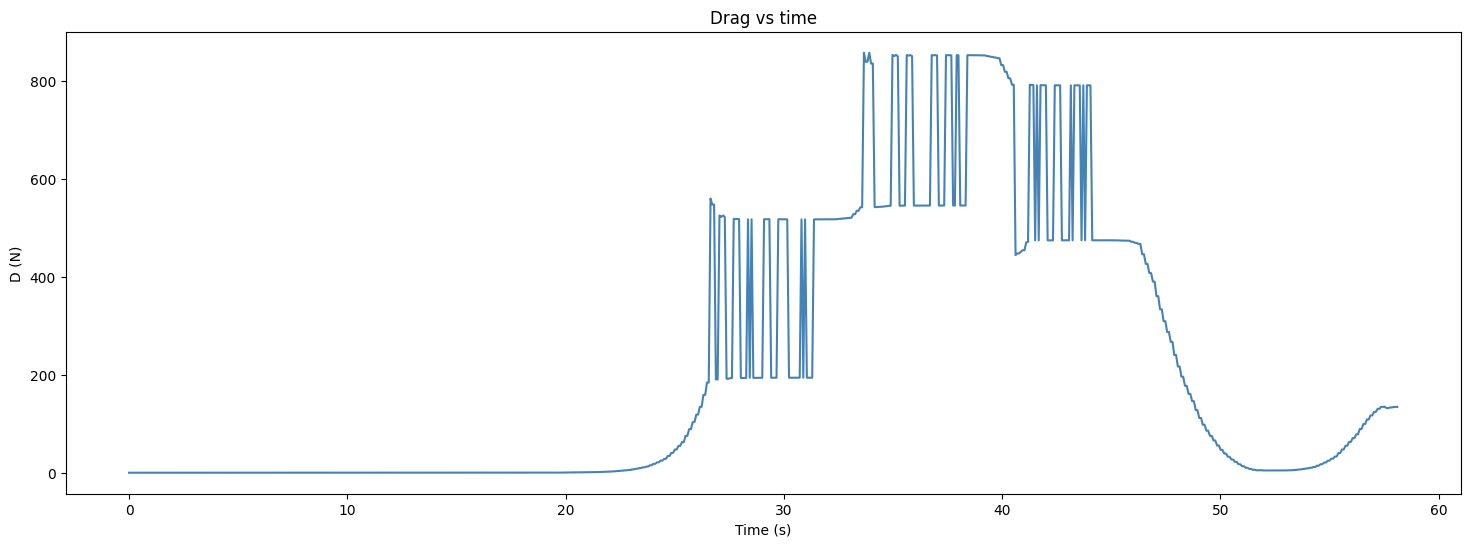

In [9]:
# 4) flight analysis
test_flight_3dof.all_info()

In [10]:
# 5) export data to a csv file for post processing
test_flight_3dof.export_trajectory('rocket3_trajectory_3dof.csv')

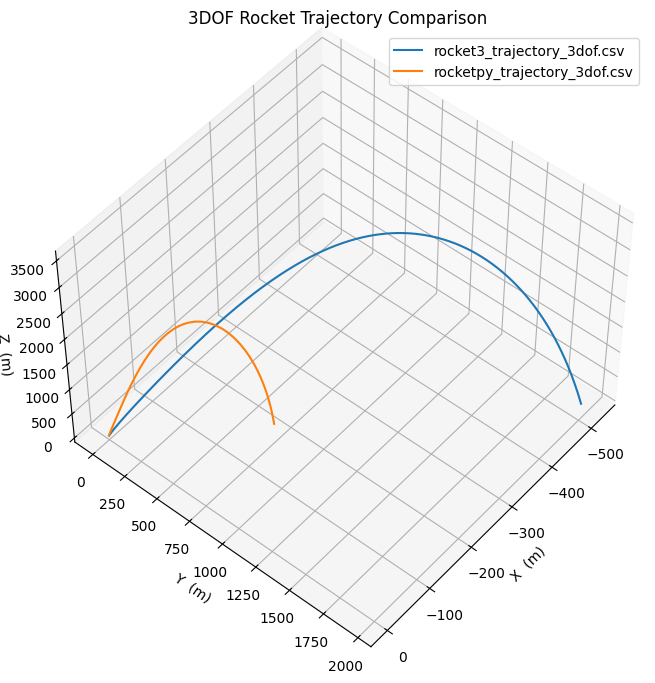

In [11]:
# 6) post processing and comparing with rocketpy 3DOF simulation
from simulator_3dof.auxiliary.comparison_functions import flight_comparison



file_paths = [
    '/Users/aitorpg/Documents/LEARNING/3DOF_simulator/tests/validation/rocket3_trajectory_3dof.csv',
    '/Users/aitorpg/Documents/LEARNING/3DOF_simulator/tests/validation/rocketpy_trajectory_3dof.csv'
]

flight_comparison(file_paths)


